In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from sympy.physics.quantum.dagger import Dagger
import math
import random
import cmath
from sympy import I, Matrix, symbols
from sympy.physics.quantum import TensorProduct
import pandas as pd
from IPython.display import clear_output


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
one = np.array([[1., 0.],[0.,1.]])
pauli_1 = np.array([[0.,1.],[1.,0.]])
pauli_2 = np.array([[0., 0-1j],[0 +1j, 0.]])
pauli_3 = np.array([[1.,0.],[0., -1.]])
plus = (1/2 * (pauli_1 + 1.j * pauli_2)).real
minus = (1/2 * (pauli_1 - 1.j * pauli_2)).real

In [4]:
#Hamiltonian
#number_of_qubits = 2
#m = 0.1

def Get_H(m, number_of_qubits):
    res_XY = torch.zeros(2**number_of_qubits, 2**number_of_qubits)
    res_mass = torch.zeros(2**number_of_qubits, 2**number_of_qubits)
    res_iter = torch.zeros(2**number_of_qubits, 2**number_of_qubits)


    # XY term
    first = one
    for i in range(1,number_of_qubits):
        #print(i)
        first = one
        second = one
        for j in range(1, number_of_qubits -i-1):
            first = TensorProduct(one, first)
            second = TensorProduct(one, second)
        if i != number_of_qubits - 1 :
            first = TensorProduct(minus, first)
            first = TensorProduct(plus, first)
            second = TensorProduct(plus, second)
            second = TensorProduct(minus, second)
        else:
            first = TensorProduct(plus, minus)
            second = TensorProduct(minus, plus)
        for j in range(1,i):
            #print("uu")
            first = TensorProduct(one, first)
            second = TensorProduct(one, second)
        #print(c.size())
        res_XY += torch.from_numpy(first + second)

    #print(res_XY)

    # mass term
    for i in range(1, number_of_qubits + 1):
        mass = one
        for j in range(1, number_of_qubits - i):
            mass = TensorProduct(one, mass)
        if i == number_of_qubits:
            mass = pauli_3
        else:
            mass = TensorProduct(pauli_3, mass)
        for j in range(1, i):
            mass = TensorProduct(one, mass)
    
        res_mass += (-1)**i * (torch.from_numpy(mass))
    
       
    #print(res_mass)

    # iteraction term
    for i in range(1,number_of_qubits ):
        res_ite = torch.zeros(2**number_of_qubits , 2**number_of_qubits)
        res_ones = torch.zeros(2**number_of_qubits , 2**number_of_qubits)
        for j in range(1, i + 1):
        
            ite = one
        
            for k in range(1, number_of_qubits - j):
                ite = TensorProduct(one, ite)
            if j == number_of_qubits:
                ite = pauli_3
            else:
                ite = TensorProduct(pauli_3, ite)
            for k in range(1, j):
                ite = TensorProduct(one, ite)
            res_ite += (torch.from_numpy(ite)) 
            ones = one
        
            for k in range(1,number_of_qubits):
                ones = TensorProduct(one, ones)
            res_ones += (-1)**j*(torch.from_numpy(ones))
        res_iter += torch.matmul(res_ones + res_ite, res_ones + res_ite)   
    
    
    return 1/4*res_iter + res_XY + m/2*res_mass 
#H = Get_H(0.2,2)
#I = torch.zeros(2**number_of_qubits,2**number_of_qubits)
#for i in range(2**number_of_qubits):
#    I[i][i] = 1.579100
#H = H +I
#print(H)

In [5]:
def matrix_element_iter_new(batch):
    batch_size = batch.shape[0]
    batch_new = torch.clone(batch)
    batch_new[batch_new == 0] = -1
    C = torch.zeros(batch_size, batch_size).to(device)
    j = torch.arange(0,batch_size,1).to(device)
    
    coef_first = number_of_qubits - number_of_qubits % 2
    coef = torch.zeros(number_of_qubits ).to(device)
    
    for i in range(number_of_qubits -1):
        coef[i] = -coef_first
        if i%2 == 0 : 
            coef_first = coef_first-2       

    C[j,j] = -(batch_new[j]*coef).sum(dim = 1)
    coef_2 = (torch.arange(number_of_qubits -2, 0, -1)*2).to(device)
    
    for i in range(0,number_of_qubits-1):
        s = torch.zeros(batch_size).to(device)
        for m in range(i+1, number_of_qubits-1):
            #print(m, coef_2[m-1])
            s += coef_2[m - 1]*batch_new[:,m]
            #print(s)
        #print(s)    
        C[j,j] += batch_new[j,i]*s[j]
       
    One = torch.eye(batch_size, batch_size).to(device)
    I = torch.tensor([range(0,number_of_qubits)]).sum()
    I += math.floor(number_of_qubits/2)
    One *= I    
    return (C + One)/4
                
            
def matrix_element_xy(batch):
    batch_size = batch.shape[0]
    batch_new = torch.clone(batch)
    batch_new[batch_new == 0] = -1
    
    place = torch.zeros(number_of_qubits -1,2)
    C = torch.zeros(batch_size, batch_size).to(device)
    
    for i in range(number_of_qubits-1):
        place[i][0]= i
        place[i][1] = i+1
    outt = torch.arange(batch_size)
    for i in outt:
        for j in outt:
            true = (torch.nonzero(batch_new[i] != batch_new[j])).reshape(-1)
            if (true.shape[0] == 2) and ((true == place).prod(dim = 1).sum()):
                C[i,j] = 1 -batch_new[i,true[0]]*batch_new[i,true[1]]
    return C/2

def matrix_element_m(batch):

    batch_new = torch.clone(batch)
    batch_size = batch.shape[0]
    batch_new[batch_new == 0] = -1
    
    t = torch.arange(0,number_of_qubits,1).to(device)
    
    batch_new[:,t] *= (-1)**(t+1)
    
    M = torch.zeros(batch_size, batch_size).to(device)
    j = torch.arange(0,batch_size,1)
    M[j,j] = -batch_new.sum(dim = 1)
        #N+= M
    return m/2*M

def matrix_element_xy_new_7(batch):
    batch_new = torch.clone(batch)
    #print(batch_new.device)
    batch_size = batch.shape[0]
    batch_new[batch_new == 0] = -1
    res = batch_new.unsqueeze(1) != batch_new
    
    place = torch.zeros(number_of_qubits -1,number_of_qubits).to(device)
    C = torch.zeros(batch_size, batch_size).to(device)
    
    for i in range(number_of_qubits-1):
        place[i][i]= 1
        place[i][i+1] = 1
        true = torch.nonzero((res == place[i]).prod(dim = 2)==1)
        ress = batch_new[true[:,0],i]*batch_new[true[:,0],i+1]
        C[true[:,0], true[:,1]] = 1 - ress
    return C/2

def matrix(batch):               
    return  matrix_element_iter_new(batch) + matrix_element_xy_new_7(batch) + matrix_element_m(batch)

In [6]:
#ok
def matrix_element_m_(one, batch, number_of_qubits, m):
    batch_new = torch.clone(batch)
    batch_size = batch.shape[0]
    batch_new[batch_new == 0] = -1
    one_new = torch.clone(one)
    one_new[one_new == 0] = -1
    
    k = (one_new == batch_new).prod(1).nonzero().to(device)
    t = torch.arange(0,number_of_qubits).to(device)
    one_new[:,t] *= (-1)**(t+1)
    M = torch.zeros(1, batch_size).to(device)
    
    M[0,k] = -one_new.sum(1)
    #print(M.shape)
    return m/2*M

#ok
def matrix_element_xy_(one, batch, number_of_qubits):
    batch_new = torch.clone(batch)
    one_new = torch.clone(one)
    #print(batch_new.device)
    batch_size = batch.shape[0]
    batch_new[batch_new == 0] = -1
    one_new[one_new == 0] = -1
    
    #res = batch_new.unsqueeze(1) != batch_new
    res = one_new != batch_new
    place = torch.zeros(number_of_qubits -1,number_of_qubits).to(device)
    C = torch.zeros(1, batch_size).to(device)
    
    for i in range(number_of_qubits-1):
        place[i][i]= 1
        place[i][i+1] = 1
        true = torch.nonzero((res == place[i]).prod(dim = 1)==1)
        ress = batch_new[true[:,0],i]*batch_new[true[:,0],i+1]
        C[0, true[:,0]] = 1 - ress
        #print(C.shape)
    return C/2

#ok
def matrix_element_iter_(one, batch, number_of_qubits):
    batch_size = batch.shape[0]
    batch_new = torch.clone(batch)
    batch_new[batch_new == 0] = -1
    one_new = torch.clone(one)
    one_new[one_new == 0] = -1
    
    C = torch.zeros(1, batch_size).to(device)
    j = torch.arange(0,batch_size,1).to(device)
    k = (one_new == batch_new).prod(1).nonzero().to(device)
    #print(k)
    coef_first = number_of_qubits - number_of_qubits % 2
    coef = torch.zeros(number_of_qubits ).to(device)
    for i in range(number_of_qubits -1):
        coef[i] = -coef_first
        if i%2 == 0 : 
            coef_first = coef_first-2       
    #print(coef)
    C[0,k] = -(one_new*coef).sum(dim = 1)
    coef_2 = (torch.arange(number_of_qubits -2, 0, -1)*2).to(device)
    
    for i in range(0,number_of_qubits-1):
        s = torch.zeros(batch_size).to(device)
        for m in range(i+1, number_of_qubits-1):
            #print(m, coef_2[m-1])
            s += coef_2[m - 1]*one_new[:,m]
            #print(s)
        #print(s)    
        C[0,k] += one_new[0,i]*s[k]
       
    One = torch.eye(batch_size, batch_size).to(device)
    I = torch.tensor([range(0,number_of_qubits)]).sum()
    I += math.floor(number_of_qubits/2)
    One *= I 
    return ((C + One[k,:])/4).view(1, batch_size)
                
def matrix_(one, batch,m, number_of_qubits):  
    return  matrix_element_iter_(one, batch, number_of_qubits) + matrix_element_xy_(one, batch, number_of_qubits) + matrix_element_m_(one, batch, number_of_qubits, m)

def mul_by_part(out, psi):
    Psi = torch.zeros(psi.shape[0]).to(device)
    for i in range(0, out.shape[0]):
        M = matrix_(out[i].view(1, out.shape[1]), out, 0.1, number_of_qubits)#.to(device)
        #print(M.shape, psi.shape)
        Psi[i] = torch.matmul(M,psi)
    print(Psi.device)
    return Psi

In [7]:
def matrix_element_m_2(one, batch, number_of_qubits, m):
    batch_new = torch.clone(batch).to(device)
    batch_size = batch.shape[0]
    batch_new[batch_new == 0] = -1
    one_new = torch.clone(one).to(device)
    one_new[one_new == 0] = -1
    
    res = ((one_new.unsqueeze(1) == batch_new).prod(dim = 2).nonzero()).to(device)
    #print(one_new.unsqueeze(1) == batch_new)
    #print(res)
    
    #k = (one_new == batch_new).prod(1).nonzero()
    t = torch.arange(0,number_of_qubits).to(device)
    one_new[:,t] *= (-1)**(t+1)
    M = torch.zeros(one.shape[0], batch_size).to(device)
    #print(res[1,0])
    
    j = torch.arange(0,res.shape[0],1).to(device)
    M[res[j,0],res[j,1]] = -one_new[j].sum(1)
    
    #M[0,k] = -one_new.sum(1)
    #print(M.shape)
    return m/2*M

def matrix_element_xy_2(one, batch, number_of_qubits):
    batch_new = torch.clone(batch).to(device)
    one_new = torch.clone(one).to(device)
    #print(batch_new.device)
    batch_size = batch.shape[0]
    batch_new[batch_new == 0] = -1
    one_new[one_new == 0] = -1
    
    
    res = (one_new.unsqueeze(1) != batch_new).to(device)
    #res = one_new != batch_new
    place = torch.zeros(number_of_qubits -1,number_of_qubits).to(device)
    C = torch.zeros(one.shape[0], batch_size).to(device)
    
    for i in range(number_of_qubits-1):
        place[i][i]= 1
        place[i][i+1] = 1
        #print(res, place[i])
        true = torch.nonzero((res == place[i]).prod(dim = 2)==1)
        ress = one_new[true[:,0],i]*one_new[true[:,0],i+1]
        C[true[:,0], true[:,1]] = 1 - ress
        #print(C.shape)
    return C/2

def matrix_element_iter_2(one, batch, number_of_qubits):
    batch_size = batch.shape[0]
    batch_new = torch.clone(batch).to(device)
    batch_new[batch_new == 0] = -1
    one_new = torch.clone(one).to(device)
    one_new[one_new == 0] = -1
    
    C = torch.zeros(one.shape[0], batch_size).to(device)
    j = torch.arange(0,one.shape[0],1).to(device)
    #k = (one_new == batch_new).prod(1).nonzero()
    
    res = ((one_new.unsqueeze(1) == batch_new).prod(dim = 2).nonzero()).to(device)
    #print(k)
    #print(res)
    coef_first = number_of_qubits - number_of_qubits % 2
    coef = torch.zeros(number_of_qubits ).to(device)
    for i in range(number_of_qubits -1):
        coef[i] = -coef_first
        if i%2 == 0 : 
            coef_first = coef_first-2       
    #print(coef)
    j = torch.arange(0,res.shape[0])
    C[res[j,0],res[j,1]] = -(one_new[j]*coef).sum(dim = 1)
    coef_2 = (torch.arange(number_of_qubits -2, 0, -1)*2)
    
    for i in range(0,number_of_qubits-1):
        s = torch.zeros(one.shape[0]).to(device)
        for m in range(i+1, number_of_qubits-1):
            #print(m, coef_2[m-1])
            s += coef_2[m - 1]*one_new[:,m]
            #print(s)
        #print(s)    
        C[res[j,0],res[j,1]] += one_new[res[j,0],i]*s[j]
       
    One = torch.eye(batch_size, batch_size).to(device)
    I = torch.tensor([range(0,number_of_qubits)]).sum()
    I += math.floor(number_of_qubits/2)
    One *= I 
    #print(C)
    C[res[j,0],res[j,1]] += I
    return C/4
                

def matrix_2(one, batch,m, number_of_qubits):  
    #print((matrix_element_iter_(one, batch, number_of_qubits)).shape)
    return  matrix_element_iter_2(one, batch, number_of_qubits) + matrix_element_xy_2(one, batch, number_of_qubits) + matrix_element_m_2(one, batch, number_of_qubits, m)

def mul_by_part_2(out, psi):
    Psi = torch.zeros(out.shape[0]).to(device)
    batch = torch.clone(out).to(device)
    t = batch.shape[0]
    half = math.ceil(t/2)
    x = torch.zeros(2,half, number_of_qubits).to(device)
    x[1] = batch[half:t, :]
    x[0] = batch[0:half, :]
    for i in range(0, 2):
        M = matrix_2(x[i], out, 0.1, number_of_qubits).to(device)
        j = torch.arange(0 ,half).to(device)
        #print(j)
        t = torch.matmul(M,psi)[j].to(device)
        #print(t.shape)
        Psi[j + i*half] = torch.matmul(M,psi)[j,0]
    return Psi

def mul_by_part_3(out, psi):
    Psi = torch.zeros(out.shape[0]).to(device)
    batch = torch.clone(out).to(device)
    t = batch.shape[0]
    half = math.ceil(t/2)
    third = math.ceil(half/3)
    x = torch.zeros(6,third, number_of_qubits).to(device)
    print(t)
    x[5] = batch[2*third + half:t, :]
    x[4] = batch[half + third:half + 2*third, :]
    x[3] = batch[half:half + third, :]
    x[2] = batch[2*third:half, :]
    x[1] = batch[third:2*third, :]
    x[0] = batch[0:third, :]
    for i in range(0, 6):
        M = matrix_2(x[i], out, 0.1, number_of_qubits).to(device)
        #print(torch.matmul(M,psi))
        j = torch.arange(0 ,third).to(device)
        #print(j)
        t = torch.matmul(M,psi)[j].to(device)
        #print(t.shape)
        Psi[j + i*third] = torch.matmul(M,psi)[j,0]
    return Psi

In [8]:
def mul_by_part_5(out, psi):
    Psi = torch.zeros(out.shape[0]).to(device)
    batch = torch.clone(out).to(device)
    t = batch.shape[0]
    half = math.ceil(t/2)
    third = math.ceil(half/3)
    f = math.ceil(third / 5)
    x = torch.zeros(30,f, number_of_qubits).to(device)
    for i in range(0,30):
        x[i] = batch[i*f : (i + 1)*f, :]
        
    for i in range(0, 30):
        #print(out.shape)
        M = matrix_2(x[i], out, 0.1, number_of_qubits).to(device)
        j = torch.arange(0 ,f)#.to(device)
        t = torch.matmul(M,psi)[j].to(device)
        Psi[j + i*f] = torch.matmul(M,psi)[j,0]
    return Psi

In [16]:
number_of_qubits = 16
from itertools import product

basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
#r = 0
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
        #print(p[i])
        #if(float(p[i]) == 0):
        #    basis[r][i] = -1
        #else:
        basis[r][i] = float(p[i])
    r -= 1
print(basis)

def make_batch(batch_size):
    return torch.randint(0,2,(batch_size,number_of_qubits)).type(torch.FloatTensor)
#basis[basis == 0] = -1

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 0., 1.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])


In [17]:
def make_batch(batch_size):
    return torch.randint(0,2,(batch_size,number_of_qubits)).type(torch.FloatTensor)

In [18]:
sum_spin = math.ceil((number_of_qubits - 1) / 2 )
print(sum_spin)
good_vectors = basis.sum(dim = 1)
good_vectors = (good_vectors == sum_spin).nonzero()[:,0]
#print(good_vectors)
sub_batch = torch.zeros(good_vectors.shape[0], number_of_qubits)
i = torch.arange(0, good_vectors.shape[0], 1)
print(i.shape, good_vectors.shape)
sub_batch[i, :] = basis[good_vectors, :]
good_batch = sub_batch
#print(sub_batch)
print(good_batch.sum(dim = 1))

8
torch.Size([12870]) torch.Size([12870])
tensor([8., 8., 8.,  ..., 8., 8., 8.])


In [19]:
def make_good_batch(size):
    i = torch.randint(sub_batch.shape[0], (1,))
    #print(i)
    batch = sub_batch[i]
    #print(batch)
    i = torch.randint(sub_batch.shape[0], (size - 1,))
    #print(i)
    for m in range(i.shape[0] , 0, -1):
        #print(sub_batch[i[m-1] + 1].view(1, number_of_qubits))
        batch = torch.cat((batch, sub_batch[i[m-1],:].view(1, number_of_qubits)), axis = 0)
    return batch

In [13]:
x = self.conv3(x)
        x = self.tanh(x)
        x = self.bn3(x)

        x = self.conv4(x)
        x = self.tanh(x)
        x = self.bn4(x)

        x = self.conv5(x)
        x = self.tanh(x)
        x = self.bn5(x)

        
        
        x = self.t_conv4(x)
        x = self.tanh(x)
        x = self.bn4(x)


        x = self.t_conv5(x)
        x = self.tanh(x)
        x = self.bn3(x)


        x = self.t_conv6(x)
        x = self.tanh(x)
        x = self.bn2(x)

IndentationError: ignored

In [21]:
class Net_CP(nn.Module):
    
    lr = 0.0005
    
    
    N_epochs = 2000
    
    def __init__(self):
        super(Net_CP,self).__init__()
        self.conv0 = nn.Conv1d(1, 1, 10, stride=1, padding = 10)
        self.conv1 = nn.Conv1d(1, 2, 9, stride=1, padding = 9)
        self.conv2 = nn.Conv1d(2, 3, 5, stride=1, padding = 8)
        self.conv3 = nn.Conv1d(3, 4, 3, stride=1, padding = 7)
        self.conv4 = nn.Conv1d(4, 5, 2, stride=1, padding =6)
        self.conv5 = nn.Conv1d(5, 6, 5, stride=1, padding = 5)
        self.conv6 = nn.Conv1d(6, 7, 4, stride=1,  padding = 4)
        self.conv7 = nn.Conv1d(7, 8, 3, stride=1,  padding = 3)
        self.conv8 = nn.Conv1d(8, 9, 2, stride=1)
        self.conv9 = nn.Conv1d(9, 10, 2, stride=1)
        
        self.Linear2 = nn.Linear((number_of_qubits - 2)*20, 100)
        self.Linear4 = nn.Linear(100, 1)
        
        self.t_conv0 = nn.ConvTranspose1d(100, 90, 2, stride=1)
        self.t_conv1 = nn.ConvTranspose1d(90, 80, 2, stride=1)
        self.t_conv2 = nn.ConvTranspose1d(80, 70, 3, stride=1, padding = 3)
        self.t_conv3 = nn.ConvTranspose1d(70, 60, 4, stride=1,  padding = 4)
        self.t_conv4 = nn.ConvTranspose1d(60, 50, 5, stride=1,  padding = 5)
        self.t_conv5 = nn.ConvTranspose1d(50, 40, 2, stride=1,  padding = 6)
        self.t_conv6 = nn.ConvTranspose1d(40, 30, 3, stride=1,  padding = 7)
        self.t_conv7 = nn.ConvTranspose1d(30, 20, 5, stride=1,  padding = 8)
        self.t_conv8 = nn.ConvTranspose1d(20, 10, 9, stride=1, padding = 9)
        self.t_conv9 = nn.ConvTranspose1d(10, 1, 10, stride=1, padding = 10)
        
        
        self.relu = nn.ReLU()
        self.bn0 = nn.BatchNorm1d(10)
        self.bn1 = nn.BatchNorm1d(20)
        self.bn2 = nn.BatchNorm1d(30)
        self.bn3 = nn.BatchNorm1d(40)
        self.bn4 = nn.BatchNorm1d(50)
        self.bn5 = nn.BatchNorm1d(60)
        self.bn6 = nn.BatchNorm1d(70)
        self.bn7 = nn.BatchNorm1d(80)
        self.bn8 = nn.BatchNorm1d(90)
        self.bn9 = nn.BatchNorm1d(100)
        self.tanh = nn.Tanh()
        
    def forward(self,x):
        #print(x.shape)
        x = self.conv0(x)
        x = self.tanh(x)
        x = self.bn0(x)
        
        x = self.conv1(x)
        x = self.tanh(x)
        x = self.bn1(x)
        
        x = self.conv2(x)
        x = self.tanh(x)
        x = self.bn2(x)

        x = self.conv3(x)
        x = self.tanh(x)
        x = self.bn3(x)

        x = self.conv4(x)
        x = self.tanh(x)
        x = self.bn4(x)

        

        x = self.t_conv5(x)
        x = self.tanh(x)
        x = self.bn3(x)


        x = self.t_conv6(x)
        x = self.tanh(x)
        x = self.bn2(x)


        x = self.t_conv7(x)
        x = self.tanh(x)
        x = self.bn1(x)


        x = self.t_conv8(x)
        x = self.tanh(x)
        x = self.bn0(x)


        x = self.t_conv9(x)
        x = self.tanh(x)
        #x = self.bn7(x)
        
        print(x.shape)
        
        x = torch.reshape(x, (good_vectors.shape[0], -1))
        #x = torch.reshape(x, (basis.shape[0], -1))
        
        x = torch.prod(x, dim = 1)
        return x
    
    
    def loss2(self,batch):
        out, num= torch.unique(batch, return_counts = True,dim = 0)
        psi = new(out)
        psi = psi/(psi.norm())
        psi = psi.view(psi.shape[0],1)
        
        out= torch.reshape(out, (out.shape[0], number_of_qubits))
        # out_CP = CP_conj(out)
        # out_CP = out_CP.unsqueeze(1).to(device)
        # psi2 = new(out_CP)
        # psi2 = psi2/(psi2.norm())
        # psi2 = psi2.view(psi2.shape[0],1)

        # Psi = (psi+psi2)/2

        
        # psi = Psi
        Psi = psi
        x = (np.arange(0,good_vectors.shape[0]))
        #x = (np.arange(0,basis.shape[0]))
        Psi = Psi.cpu().detach().numpy()
        #clear_output()
        plt.scatter(x, Psi**2, alpha = 1, label='ideal')
        plt.show()
        out= torch.reshape(out, (out.shape[0], number_of_qubits))
        #print(out.shape, 'QQQQQQQ')
        psi = psi/psi.norm()
        #M = 
        #M = mul_by_part(out, psi)
        #E = torch.matmul(psi.view(1, -1),M)
        #E = torch.matmul(torch.transpose(psi, 0, 1), torch.matmul(M, psi))
        #print(E)
        E = torch.matmul(torch.transpose(psi, 0, 1), mul_by_part_5(out, psi))
        return E
    
    def optimize(self,inp):
        optimizer = torch.optim.Adam(self.parameters(), lr = self.lr, betas=(0.9, 0.999))###
        #optimizer = torch.optim.SGD(self.parameters(), self.lr, momentum= 0.5) 
        distance = []
        count = 0
        #scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[2000,10000], gamma=0.1)
        for i in tqdm(range(self.N_epochs)): #tqdm показывет процесс выполенения в процентах
            optimizer.zero_grad()
            
            #inp = self.sample2(inp,i)
            loss_curr = self.loss2(inp)
        
            if i == self.N_epochs - 1:
                print(loss_curr)
                
            loss_curr.backward()
            optimizer.step() # parameter update
            distance.append(loss_curr.view(1).cpu().detach().numpy())# To stop a tensor from tracking history, you can call .detach() 
            count += 1
            if count == 100:
                clear_output()
                plt.plot(distance)
                plt.show()
                print(loss_curr)
                count = 0
                np.save('number_of_qubits_{}_iter{}'.format( number_of_qubits, i), new(inp).cpu().detach().numpy())
        return distance

In [22]:
def CP_conj(batch):
    add = torch.clone(batch)
    CP_batch = torch.clone(batch)
    i = torch.arange(0,number_of_qubits/2,1).type(torch.LongTensor)
    j = torch.arange(number_of_qubits-1, number_of_qubits/2-1, -1).type(torch.LongTensor)
    CP_batch[:,i] = CP_batch[:,j]
    CP_batch[:,j] = add[:,i]
    add = torch.clone(CP_batch)

    CP_batch[add == 0] = 1
    CP_batch[add == 1] = 0
    return CP_batch

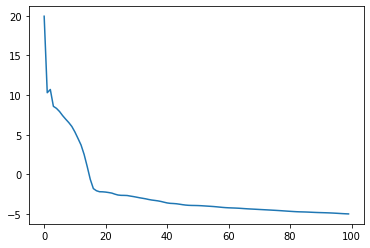

  5%|▌         | 100/2000 [48:58<15:36:09, 29.56s/it]

tensor([-4.9677], device='cuda:0', grad_fn=<MvBackward>)
torch.Size([12870, 1, 16])
torch.Size([12870, 1, 16])


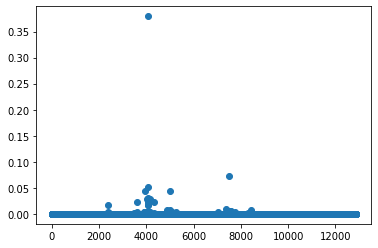

  5%|▌         | 101/2000 [49:27<15:34:04, 29.51s/it]

torch.Size([12870, 1, 16])


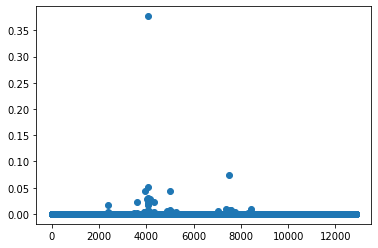

  5%|▌         | 102/2000 [49:57<15:33:04, 29.50s/it]

torch.Size([12870, 1, 16])


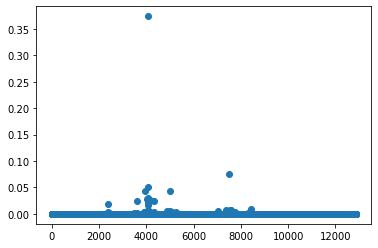

  5%|▌         | 103/2000 [50:26<15:31:58, 29.48s/it]

torch.Size([12870, 1, 16])


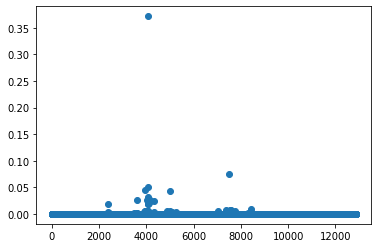

  5%|▌         | 104/2000 [50:56<15:31:22, 29.47s/it]

torch.Size([12870, 1, 16])


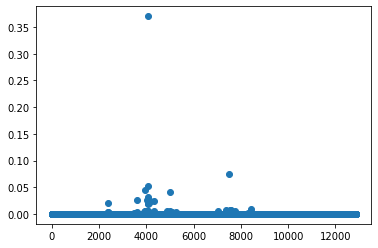

  5%|▌         | 105/2000 [51:25<15:30:29, 29.46s/it]

torch.Size([12870, 1, 16])


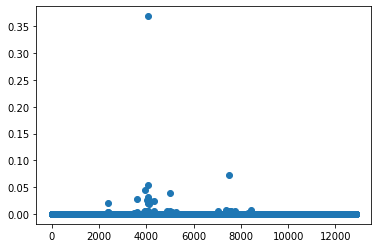

  5%|▌         | 106/2000 [51:54<15:29:23, 29.44s/it]

torch.Size([12870, 1, 16])


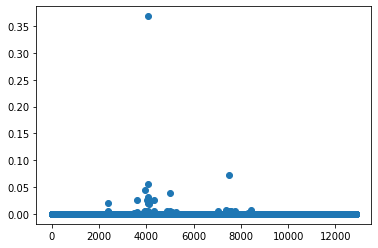

  5%|▌         | 107/2000 [52:24<15:28:34, 29.43s/it]

torch.Size([12870, 1, 16])


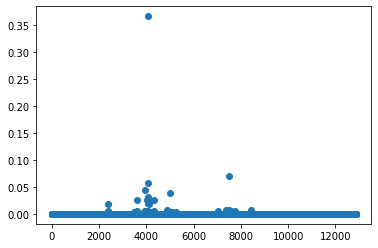

  5%|▌         | 108/2000 [52:53<15:28:25, 29.44s/it]

torch.Size([12870, 1, 16])


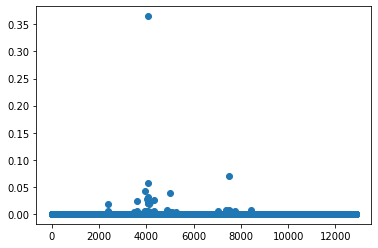

  5%|▌         | 109/2000 [53:23<15:29:00, 29.48s/it]

torch.Size([12870, 1, 16])


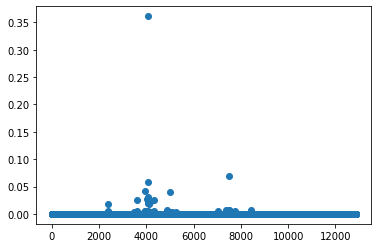

  6%|▌         | 110/2000 [53:52<15:29:26, 29.51s/it]

torch.Size([12870, 1, 16])


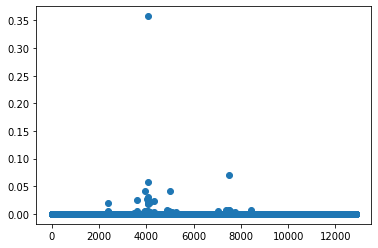

  6%|▌         | 111/2000 [54:22<15:28:01, 29.48s/it]

torch.Size([12870, 1, 16])


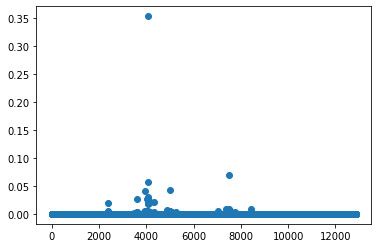

In [ ]:
new = Net_CP().to(device)
print(new)
m = 0.1

pick = math.ceil((2**number_of_qubits*0.33))
batch_size = good_batch.shape[0]
batch = good_batch
batch = batch.unsqueeze(1).to(device)
print(batch.shape)

#batch = torch.clone(basis).unsqueeze(1).to(device)

dist = new.optimize(batch)
plt.plot(dist[1:])

print('exact solution ={}'.format(c))

In [ ]:
import time
c = good_batch.to(device)
psi = torch.rand(c.shape[0]).to(device)
start_time = time.time()
n = mul_by_part(c, psi)
print("--- %s seconds ---" % (time.time() - start_time))

--- 2.6289680004119873 seconds ---


In [ ]:
torch.set_printoptions(precision=5)
m = 0.1
H = Get_H(m, number_of_qubits)
eig_values = torch.eig(H, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(H, eigenvectors = True)[1]
c = eig_values.min()
m = torch.min(eig_values,0)[1]
R = eig_vector[:,m].reshape(2**number_of_qubits)
print(c)
#min_vector = eig_vector[:,m].reshape(1,2**number_of_qubits)


tensor(-3.45945)


torch.Size([70, 1, 8])
torch.Size([70, 8])
torch.Size([70])
torch.Size([70, 1])
tensor(1.)
tensor(1.) tensor(1.)


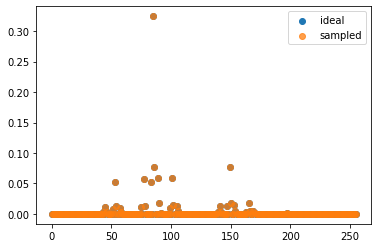

In [ ]:
basiss = torch.clone(good_batch).unsqueeze(1).to(device)
#basiss = torch.clone(basis).unsqueeze(1).to(device)
print(basiss.shape)
T = new(basiss).detach().cpu()
T = (T/T.norm()).view(T.shape[0], -1)
print(T.shape)
my_way = torch.zeros(2**number_of_qubits, 1)
my_way[good_vectors, :] = T[i, :]
#my_way = T
#print(my_way)
#print(torch.matmul(torch.transpose(T.view(basis.shape[0],1), 0, 1), torch.matmul(H, T)))
import matplotlib.colors as mcolors
a = R**2
#a = num_12
print(my_way.norm())
x = np.arange(0,2**number_of_qubits)
y = np.random.randint(1, 20, size = 2**number_of_qubits)

z = torch.zeros(2**number_of_qubits)
#z = T**2
z = my_way**2
print(z.sum(), a.sum())
fig, ax = plt.subplots()
ax.scatter(x, a, alpha = 1, label='ideal')
ax.scatter(x, z, alpha = 0.75, label='sampled')
#ax.set_xticks(x)
ax.legend()
plt.show()

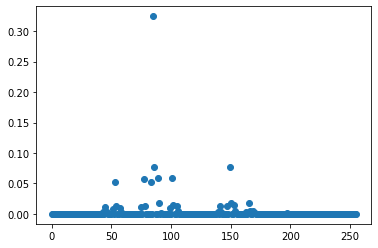

In [ ]:
plt.scatter(x, a, alpha = 1, label='ideal')

In [ ]:
number_of_qubits = 10
from itertools import product

basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
#r = 0
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
        #print(p[i])
        #if(float(p[i]) == 0):
        #    basis[r][i] = -1
        #else:
        basis[r][i] = float(p[i])
    r -= 1
print(basis)

def make_batch(batch_size):
    return torch.randint(0,2,(batch_size,number_of_qubits)).type(torch.FloatTensor)
#basis[basis == 0] = -1

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 0., 1.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])


In [ ]:
m = 0.1
H1 = Get_H(m, number_of_qubits)

torch.set_printoptions(precision=5)
eig_values1 = torch.eig(H1, eigenvectors = True)[0][:, 0]
eig_vector1 = torch.eig(H1, eigenvectors = True)[1]
c = eig_values1.min()
m = torch.min(eig_values1,0)[1]
R = eig_vector1[:,m].reshape(2**number_of_qubits)
print(c,m)

tensor(-4.40245) tensor(124)


In [ ]:
np.save('number_of_qubits_{}'.format( number_of_qubits), R)


In [ ]:
#num_12 = np.load('number_of_qubits_12.npy')**2
sum_spin = math.ceil((number_of_qubits - 1) / 2 )
print(sum_spin)
good_vectors = basis.sum(dim = 1)
good_vectors = (good_vectors == sum_spin).nonzero()[:,0]
#print(good_vectors)
sub_batch = torch.zeros(good_vectors.shape[0], number_of_qubits)
i = torch.arange(0, good_vectors.shape[0], 1)
print(i.shape, good_vectors.shape)
sub_batch[i, :] = basis[good_vectors, :]
good_batch = sub_batch


good_batch_ = good_batch.unsqueeze(1).to(device)
#good_batch_ = basis.unsqueeze(1).to(device)
T = new(good_batch_).detach().cpu()

T = T/T.norm()
T = T.view(T.shape[0], 1)
my_way = torch.zeros(2**number_of_qubits, 1)
print(my_way.shape)
print(T.shape)
i = torch.arange(0, good_vectors.shape[0], 1)
my_way[good_vectors, :] = T[i, :]
#my_way = T
#print(my_way)

5
torch.Size([252]) torch.Size([252])
torch.Size([252, 10])
torch.Size([252])
torch.Size([1024, 1])
torch.Size([252, 1])


tensor(1.00000)
tensor(1.00000) tensor(1.)


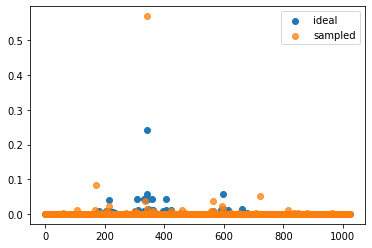

In [ ]:
import matplotlib.colors as mcolors
#a = num_12
print(my_way.norm())
x = np.arange(0,2**number_of_qubits)
y = np.random.randint(1, 20, size = 2**number_of_qubits)
#for i in range(0,2**number_of_qubits):
#    y[i] = a[i]

z = torch.zeros(2**number_of_qubits)
#for i in range(0,2**number_of_qubits):
#    z[i] = times[i]
#z = T**2
z = my_way**2
print(z.sum(), a.sum())
fig, ax = plt.subplots()
ax.scatter(x, R**2, alpha = 1, label='ideal')
ax.scatter(x, z, alpha = 0.75, label='sampled')
#ax.set_xticks(x)
ax.legend()
plt.show()

In [ ]:
z[15], z[240]
print(basis[484], basis[865])
print(CP_conj(basis[484].view(1,10)))
print(z[484], z[865])

tensor([0., 1., 1., 1., 1., 0., 0., 1., 0., 0.]) tensor([1., 1., 0., 1., 1., 0., 0., 0., 0., 1.])
tensor([[1., 1., 0., 1., 1., 0., 0., 0., 0., 1.]])
tensor([0.00017]) tensor([0.00017])


tensor(1.00000) tensor(1.00000)


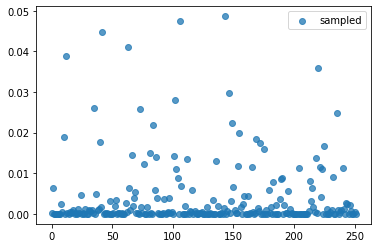

In [ ]:
x = np.arange(0,good_vectors.shape[0])
y = np.random.randint(1, 20, size = 2**number_of_qubits)

z = torch.zeros(2**number_of_qubits)
z = T**2
#z = my_way**2
print(z.sum(), a.sum())
fig, ax = plt.subplots()
#ax.scatter(x, a, alpha = 1, label='ideal')
ax.scatter(x, z, alpha = 0.75, label='sampled')
#ax.set_xticks(x)
ax.legend()
plt.show()

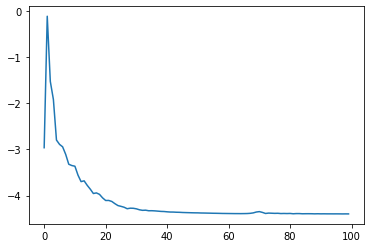







  5%|▌         | 100/2000 [00:16<06:39,  4.75it/s]

tensor([[-4.39851]], device='cuda:0', grad_fn=<MmBackward>)
torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


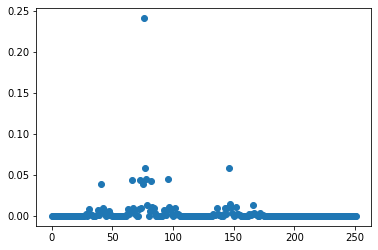







  5%|▌         | 101/2000 [00:17<05:58,  5.30it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


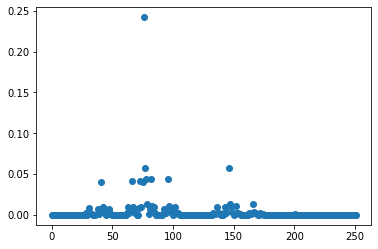







  5%|▌         | 102/2000 [00:17<05:29,  5.75it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


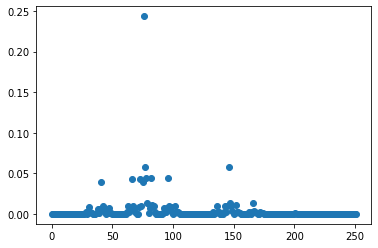







  5%|▌         | 103/2000 [00:17<05:12,  6.06it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


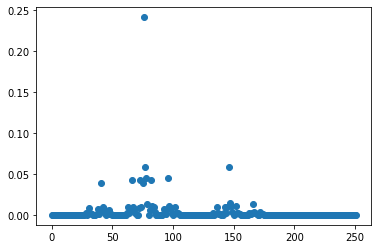







  5%|▌         | 104/2000 [00:17<05:01,  6.29it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


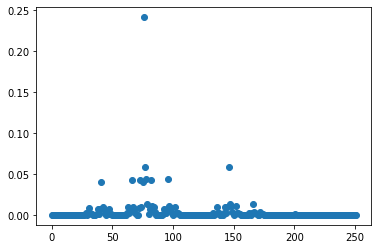







  5%|▌         | 105/2000 [00:17<04:53,  6.46it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


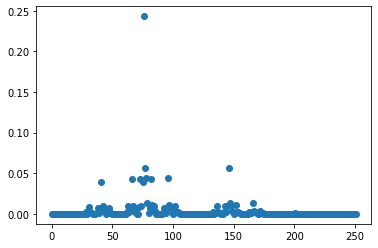







  5%|▌         | 106/2000 [00:17<04:55,  6.42it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


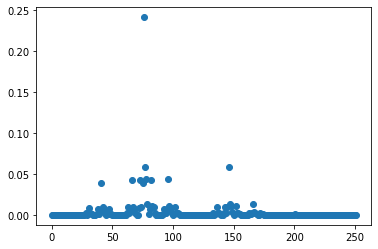







  5%|▌         | 107/2000 [00:18<05:58,  5.28it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


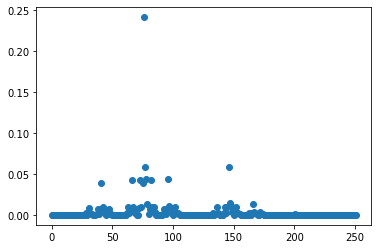







  5%|▌         | 108/2000 [00:18<05:38,  5.59it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


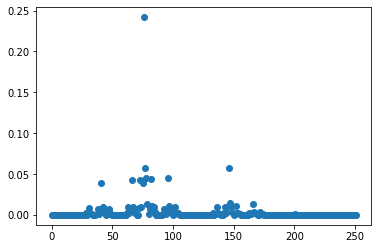







  5%|▌         | 109/2000 [00:18<05:26,  5.79it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


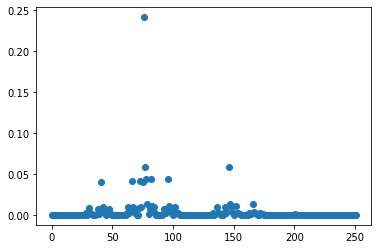







  6%|▌         | 110/2000 [00:18<05:21,  5.88it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


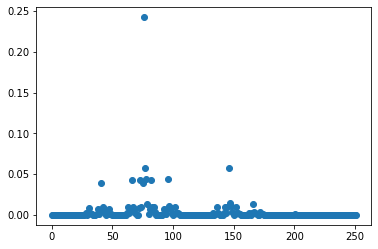







  6%|▌         | 111/2000 [00:18<05:14,  6.00it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


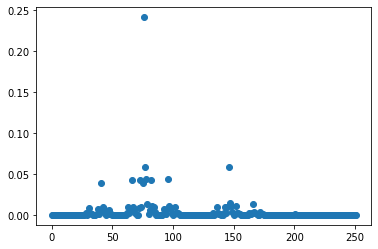







  6%|▌         | 112/2000 [00:18<05:08,  6.13it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


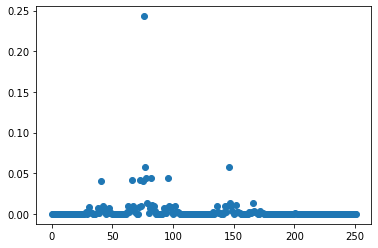







  6%|▌         | 113/2000 [00:19<05:03,  6.21it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


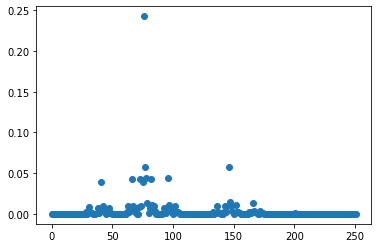







  6%|▌         | 114/2000 [00:19<04:59,  6.29it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


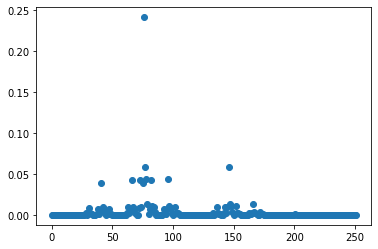







  6%|▌         | 115/2000 [00:19<04:53,  6.42it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


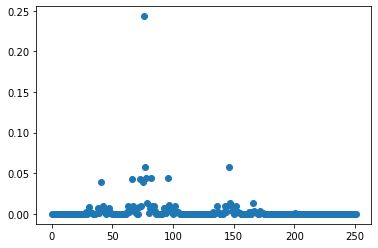







  6%|▌         | 116/2000 [00:19<04:46,  6.57it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


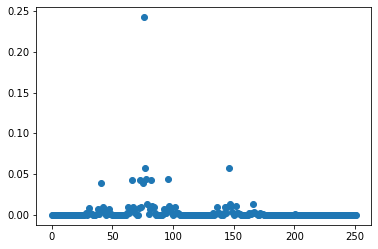







  6%|▌         | 117/2000 [00:19<04:50,  6.47it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


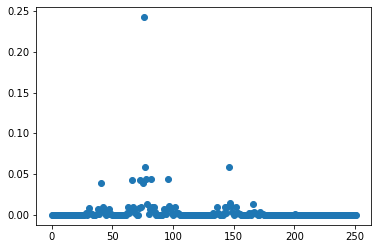







  6%|▌         | 118/2000 [00:19<04:48,  6.53it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


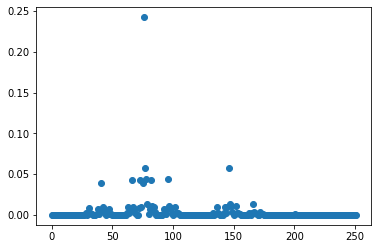







  6%|▌         | 119/2000 [00:19<04:45,  6.60it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


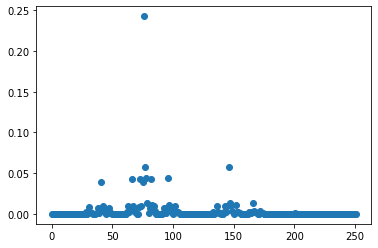







  6%|▌         | 120/2000 [00:20<04:46,  6.57it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


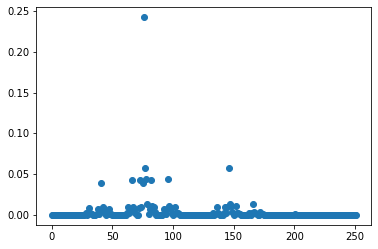







  6%|▌         | 121/2000 [00:20<04:42,  6.64it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


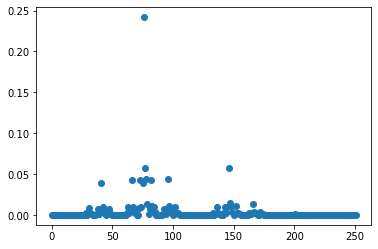







  6%|▌         | 122/2000 [00:20<04:44,  6.61it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


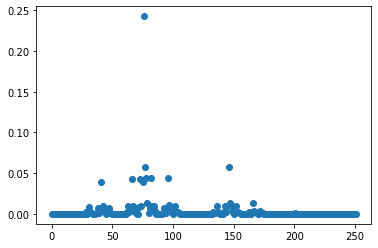







  6%|▌         | 123/2000 [00:20<04:40,  6.69it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


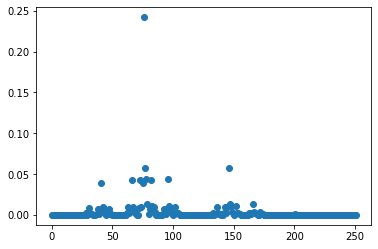







  6%|▌         | 124/2000 [00:20<04:41,  6.67it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


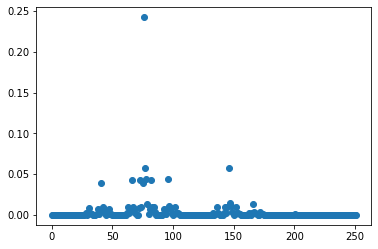







  6%|▋         | 125/2000 [00:20<04:42,  6.64it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


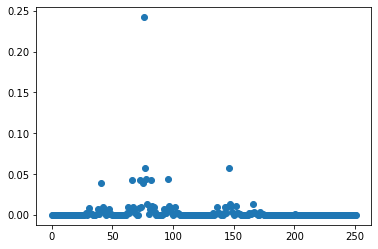







  6%|▋         | 126/2000 [00:20<04:47,  6.52it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


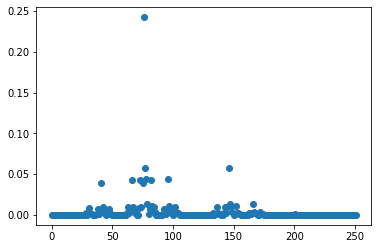







  6%|▋         | 127/2000 [00:21<04:47,  6.52it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


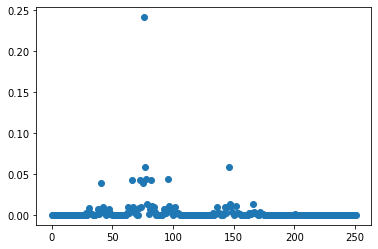







  6%|▋         | 128/2000 [00:21<04:49,  6.47it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


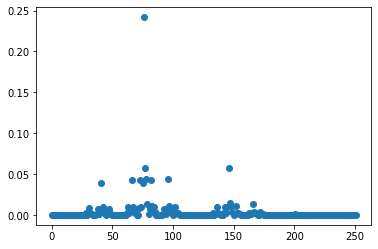







  6%|▋         | 129/2000 [00:21<05:46,  5.39it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


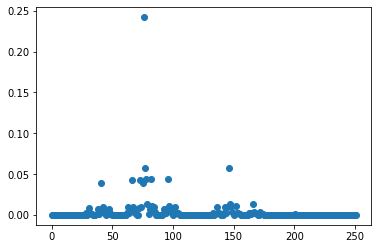







  6%|▋         | 130/2000 [00:21<05:34,  5.59it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


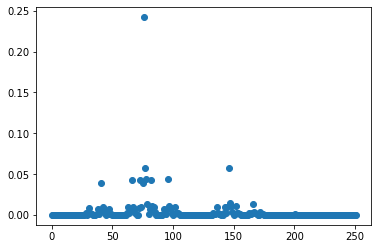







  7%|▋         | 131/2000 [00:21<05:25,  5.74it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


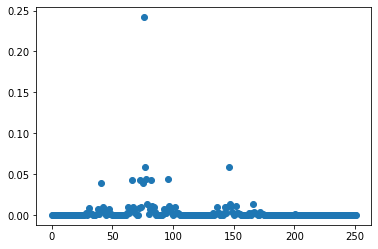







  7%|▋         | 132/2000 [00:22<05:21,  5.81it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


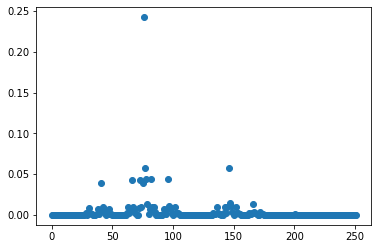







  7%|▋         | 133/2000 [00:22<05:17,  5.87it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


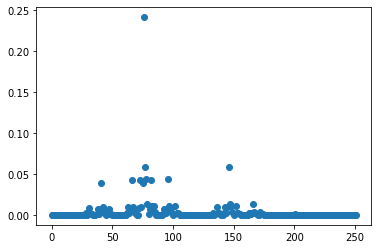







  7%|▋         | 134/2000 [00:22<05:18,  5.86it/s]

torch.Size([252, 1, 10])
torch.Size([252, 1, 10])


KeyboardInterrupt: ignored

In [ ]:
m = 0.1

pick = math.ceil((2**number_of_qubits*0.33))
batch_size = good_batch.shape[0]
batch = good_batch
batch = batch.unsqueeze(1).to(device)
print(batch.shape)


dist = new.optimize(batch)
plt.plot(dist[1:])

print('exact solution ={}'.format(c))

In [ ]:
class Net_half(nn.Module):
    
    lr = 0.0005
    
    
    N_epochs = 2000
    
    def __init__(self):
        super(Net_half,self).__init__()
        self.conv0 = nn.Conv1d(1, 10, 10, stride=1, padding = 10)
        self.conv1 = nn.Conv1d(10, 20, 9, stride=1, padding = 9)
        self.conv2 = nn.Conv1d(20, 30, 5, stride=1, padding = 8)
        self.conv3 = nn.Conv1d(30, 40, 3, stride=1, padding = 7)
        self.conv4 = nn.Conv1d(40, 50, 2, stride=1, padding =6)
        self.conv5 = nn.Conv1d(50, 60, 5, stride=1, padding = 5)
        self.conv6 = nn.Conv1d(60, 70, 4, stride=1,  padding = 4)
        self.conv7 = nn.Conv1d(70, 80, 3, stride=1,  padding = 3)
        self.conv8 = nn.Conv1d(80, 90, 2, stride=1)
        self.conv9 = nn.Conv1d(90, 100, 2, stride=1)
        
        self.Linear2 = nn.Linear((number_of_qubits - 2)*20, 100)
        self.Linear4 = nn.Linear(100, 1)
        
        self.t_conv0 = nn.ConvTranspose1d(100, 90, 2, stride=1)
        self.t_conv1 = nn.ConvTranspose1d(90, 80, 2, stride=1)
        self.t_conv2 = nn.ConvTranspose1d(80, 70, 3, stride=1, padding = 3)
        self.t_conv3 = nn.ConvTranspose1d(70, 60, 4, stride=1,  padding = 4)
        self.t_conv4 = nn.ConvTranspose1d(60, 50, 5, stride=1,  padding = 5)
        self.t_conv5 = nn.ConvTranspose1d(50, 40, 2, stride=1,  padding = 6)
        self.t_conv6 = nn.ConvTranspose1d(40, 30, 3, stride=1,  padding = 7)
        self.t_conv7 = nn.ConvTranspose1d(30, 20, 5, stride=1,  padding = 8)
        self.t_conv8 = nn.ConvTranspose1d(20, 10, 9, stride=1, padding = 9)
        self.t_conv9 = nn.ConvTranspose1d(10, 1, 10, stride=1, padding = 10)
        
        
        self.relu = nn.ReLU()
        self.bn0 = nn.BatchNorm1d(10)
        self.bn1 = nn.BatchNorm1d(20)
        self.bn2 = nn.BatchNorm1d(30)
        self.bn3 = nn.BatchNorm1d(40)
        self.bn4 = nn.BatchNorm1d(50)
        self.bn5 = nn.BatchNorm1d(60)
        self.bn6 = nn.BatchNorm1d(70)
        self.bn7 = nn.BatchNorm1d(80)
        self.bn8 = nn.BatchNorm1d(90)
        self.bn9 = nn.BatchNorm1d(100)
        self.tanh = nn.Tanh()
        
    def forward(self,x):
        #print(x.shape)
        x = self.conv0(x)
        x = self.tanh(x)
        x = self.bn0(x)
        
        x = self.conv1(x)
        x = self.tanh(x)
        x = self.bn1(x)
        
        x = self.conv2(x)
        x = self.tanh(x)
        x = self.bn2(x)

        x = self.conv3(x)
        x = self.tanh(x)
        x = self.bn3(x)

        x = self.conv4(x)
        x = self.tanh(x)
        x = self.bn4(x)

        

        x = self.t_conv5(x)
        x = self.tanh(x)
        x = self.bn3(x)


        x = self.t_conv6(x)
        x = self.tanh(x)
        x = self.bn2(x)


        x = self.t_conv7(x)
        x = self.tanh(x)
        x = self.bn1(x)


        x = self.t_conv8(x)
        x = self.tanh(x)
        x = self.bn0(x)


        x = self.t_conv9(x)
        x = self.tanh(x)
        #x = self.bn7(x)
        
        print(x.shape)
        
        x = torch.reshape(x, (x.shape[0], -1))
        
        x = torch.prod(x, dim = 1)
        return x
    
    
    def loss2(self,batch):
        out, num= torch.unique(batch, return_counts = True,dim = 0)
        psi = new(out)
        psi = psi/(psi.norm())
        psi = psi.view(psi.shape[0],1)
        
        out= torch.reshape(out, (out.shape[0], out.shape[2]))
        batch = out

        t = torch.zeros(1,10).to(device)
        Psi = torch.zeros(252).to(device)
        k = 0
        sum = batch.sum(dim = 1)
        for i in range(2**5):
          place =((sum[i] + sum) == 5).nonzero()
          for j in place:
            res = torch.cat((batch[i],batch[j].view(5)), 0)
            Psi[k] = psi[j] * psi[i]
            t = torch.cat((t,res.view(1,10)), 0).to(device)
            k +=1
        t = torch.cat((t[:0,:], t[1:,:]), axis = 0)
        psi = Psi
        
        x = (np.arange(0,good_vectors.shape[0]))
        Psi = Psi.cpu().detach().numpy()

        my_way = torch.zeros(2**number_of_qubits, 1)
        i = torch.arange(0, good_vectors.shape[0], 1)
        my_way[good_vectors, :] = Psi[i]
        
        plt.scatter(x, my_way**2, alpha = 1, label='ideal')
        plt.show()

        psi = psi.view(psi.shape[0],1)
        psi = psi/(psi.norm())
        print(psi[0], psi[251])
        M = matrix(t)
        E = torch.matmul(torch.transpose(psi, 0, 1), torch.matmul(M, psi))
        #print(E)
        return E
    
    def optimize(self,inp):
        optimizer = torch.optim.Adam(self.parameters(), lr = self.lr, betas=(0.9, 0.999))###
        #optimizer = torch.optim.SGD(self.parameters(), self.lr, momentum= 0.5) 
        distance = []
        count = 0
        #scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[2000,10000], gamma=0.1)
        for i in tqdm(range(self.N_epochs)): #tqdm показывет процесс выполенения в процентах
            optimizer.zero_grad()
            
            #inp = self.sample2(inp,i)
            loss_curr = self.loss2(inp)
        
            if i == self.N_epochs - 1:
                print(loss_curr)
                
            loss_curr.backward()
            optimizer.step() # parameter update
            distance.append(loss_curr.view(1).cpu().detach().numpy())# To stop a tensor from tracking history, you can call .detach() 
            count += 1
            if count == 100:
                clear_output()
                plt.plot(distance)
                plt.show()
                print(loss_curr)
                count = 0
        return distance

In [ ]:
new = Net_half().to(device)
print(new)
m = 0.1
number_of_qubits = 10
pick = math.ceil((2**number_of_qubits*0.33))
batch_size = good_batch.shape[0]
batch = good_batch
batch = batch.unsqueeze(1).to(device)
print(batch.shape)
batch = torch.clone(basis).unsqueeze(1).to(device)

dist = new.optimize(batch)
plt.plot(dist[1:])

print('exact solution ={}'.format(c))











  0%|          | 0/2000 [00:00<?, ?it/s]

Net_half(
  (conv0): Conv1d(1, 10, kernel_size=(10,), stride=(1,), padding=(10,))
  (conv1): Conv1d(10, 20, kernel_size=(9,), stride=(1,), padding=(9,))
  (conv2): Conv1d(20, 30, kernel_size=(5,), stride=(1,), padding=(8,))
  (conv3): Conv1d(30, 40, kernel_size=(3,), stride=(1,), padding=(7,))
  (conv4): Conv1d(40, 50, kernel_size=(2,), stride=(1,), padding=(6,))
  (conv5): Conv1d(50, 60, kernel_size=(5,), stride=(1,), padding=(5,))
  (conv6): Conv1d(60, 70, kernel_size=(4,), stride=(1,), padding=(4,))
  (conv7): Conv1d(70, 80, kernel_size=(3,), stride=(1,), padding=(3,))
  (conv8): Conv1d(80, 90, kernel_size=(2,), stride=(1,))
  (conv9): Conv1d(90, 100, kernel_size=(2,), stride=(1,))
  (Linear2): Linear(in_features=160, out_features=100, bias=True)
  (Linear4): Linear(in_features=100, out_features=1, bias=True)
  (t_conv0): ConvTranspose1d(100, 90, kernel_size=(2,), stride=(1,))
  (t_conv1): ConvTranspose1d(90, 80, kernel_size=(2,), stride=(1,))
  (t_conv2): ConvTranspose1d(80, 70, ke

ValueError: ignored

In [ ]:
batch = basis

sum = batch.sum(dim = 1)
print(sum)
print(batch.shape)

tensor([0., 1., 1., 2., 1., 2., 2., 3., 1., 2., 2., 3., 2., 3., 3., 4., 1., 2.,
        2., 3., 2., 3., 3., 4., 2., 3., 3., 4., 3., 4., 4., 5.])
torch.Size([32, 5])


In [ ]:
t = torch.zeros(1,10)
psi = torch.rand(252)
Psi = torch.zeros(252)
print(psi.shape)
k = 0
for i in range(2**5):
  place =((sum[i] + sum) == 5).nonzero()
  for j in place:
    res = torch.cat((batch[i],batch[j].view(5)), 0)
    Psi[k] = psi[j] * psi[i]
    t = torch.cat((t,res.view(1,10)), 0)
    k +=1
print(k)
print(t.shape)
print((t.sum(1)!= 5).nonzero())
t = torch.cat((t[:0,:], t[1:,:]), axis = 0)
print(t.shape)
print(Psi[0], Psi[251])

torch.Size([252])
252
torch.Size([253, 10])
tensor([[0]])
torch.Size([252, 10])
tensor(0.1813) tensor(0.1813)


In [ ]:
number_of_qubits = 5
from itertools import product

basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
#r = 0
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
        #print(p[i])
        #if(float(p[i]) == 0):
        #    basis[r][i] = -1
        #else:
        basis[r][i] = float(p[i])
    r -= 1


In [ ]:

b = torch.cat((batch, batch), 0)
b = b.view(64,5)
print(b)
batch = batch.view(32,5)
print((b batch))
print(t.shape)
print((t.sum(1)!= 5).nonzero())
t, num= torch.unique(t, return_counts = True,dim = 0)
print(t.shape)

SyntaxError: ignored